# 05 - Directional Regime-Aware Classifier

Notebook 04 predicted the exact next-day return. That is difficult because daily returns are noisy.

This notebook predicts market direction instead:

- `1` = next day up
- `0` = next day down

We compare:

- Baseline classifier trained on all data
- Hard-routed regime expert classifiers
- Soft-gated regime expert classifiers

Input: `../data/processed/regime_features.csv`  
Output: `../data/processed/directional_model_metrics.csv` and `../data/processed/directional_predictions.csv`

## Why This Notebook Matters

In finance, predicting the exact return is very hard. A model can have weak RMSE but still be useful if it predicts direction well.

Important terms:

- **Classification**: predicting a category, such as up or down.
- **Probability of up**: model confidence that tomorrow's return will be positive.
- **Trading signal**: if probability is above a threshold, take a long position.
- **Regime-aware classifier**: different classifiers specialize in Bull, Bear, and Crisis regimes.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

plt.style.use("seaborn-v0_8-whitegrid")

## 1. Load Regime Dataset

This comes from notebook 03. It contains engineered features, HMM regime labels, and next-day direction labels.

In [2]:
DATA_PATH = Path("../data/processed/regime_features.csv")
OUTPUT_DIR = Path("../data/processed")

regime_df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
regime_df = regime_df.sort_values("Date").reset_index(drop=True)

print(regime_df.shape)
print(regime_df["regime_label"].value_counts())
regime_df.head()

(623, 17)
regime_label
Bear      412
Bull      118
Crisis     93
Name: count, dtype: int64


,Date,ticker,Close,return_1d,volatility_30d,momentum_30d,ma_50_ratio,ma_200_ratio,drawdown,vix_close,target_return_1d,target_direction_1d,regime,regime_label,regime_0_prob,regime_1_prob,regime_2_prob
0,2010-04-27,^GSPC,1183.709961,-0.023382,0.007319,0.028857,0.020765,NaN,-0.027578,22.809999,0.006463,1,1,Bull,5.500702e-12,1.000000,1.553645e-11
1,2010-04-28,^GSPC,1191.359985,0.006463,0.007280,0.027513,0.025655,NaN,-0.021293,21.080000,0.012943,1,0,Bear,9.833277e-01,0.016623,4.970221e-05
2,2010-04-29,^GSPC,1206.780029,0.012943,0.007556,0.034788,0.037015,NaN,-0.008626,18.440001,-0.016648,0,0,Bear,9.994668e-01,0.000531,1.791272e-06
3,2010-04-30,^GSPC,1186.689941,-0.016648,0.008225,0.017893,0.018352,NaN,-0.025130,22.049999,0.013121,1,0,Bear,9.998941e-01,0.000065,4.078930e-05
4,2010-05-03,^GSPC,1202.260010,0.013121,0.008458,0.036520,0.030068,NaN,-0.012339,20.190001,-0.023838,0,0,Bear,9.986716e-01,0.000053,1.275341e-03


## 2. Select Features And Target

Target:

- `target_direction_1d`

This is created in notebook 02:

```text
1 = tomorrow return > 0
0 = tomorrow return <= 0
```

In [3]:
feature_cols = [
    "return_1d",
    "volatility_30d",
    "momentum_30d",
    "ma_50_ratio",
    "drawdown",
    "vix_close",
    "regime_0_prob",
    "regime_1_prob",
    "regime_2_prob",
]

target_col = "target_direction_1d"
return_col = "target_return_1d"

data = regime_df.replace([np.inf, -np.inf], np.nan).copy()
data = data.dropna(subset=feature_cols + [target_col, return_col, "regime_label"]).reset_index(drop=True)

data[target_col] = data[target_col].astype(int)

print(data.shape)
print(data[target_col].value_counts(normalize=True))
data[["Date", "Close", "regime_label"] + feature_cols + [target_col, return_col]].head()

(623, 17)
target_direction_1d
1    0.544141
0    0.455859
Name: proportion, dtype: float64


,Date,Close,regime_label,return_1d,volatility_30d,momentum_30d,ma_50_ratio,drawdown,vix_close,regime_0_prob,regime_1_prob,regime_2_prob,target_direction_1d,target_return_1d
0,2010-04-27,1183.709961,Bull,-0.023382,0.007319,0.028857,0.020765,-0.027578,22.809999,5.500702e-12,1.000000,1.553645e-11,1,0.006463
1,2010-04-28,1191.359985,Bear,0.006463,0.007280,0.027513,0.025655,-0.021293,21.080000,9.833277e-01,0.016623,4.970221e-05,1,0.012943
2,2010-04-29,1206.780029,Bear,0.012943,0.007556,0.034788,0.037015,-0.008626,18.440001,9.994668e-01,0.000531,1.791272e-06,0,-0.016648
3,2010-04-30,1186.689941,Bear,-0.016648,0.008225,0.017893,0.018352,-0.025130,22.049999,9.998941e-01,0.000065,4.078930e-05,1,0.013121
4,2010-05-03,1202.260010,Bear,0.013121,0.008458,0.036520,0.030068,-0.012339,20.190001,9.986716e-01,0.000053,1.275341e-03,0,-0.023838


## 3. Time-Based Split

We split by time to avoid look-ahead bias.

The model trains on the past and tests on the future.

In [4]:
split_idx = int(len(data) * 0.8)

train_df = data.iloc[:split_idx].copy()
test_df = data.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]

print("Train period:", train_df["Date"].min(), "to", train_df["Date"].max())
print("Test period:", test_df["Date"].min(), "to", test_df["Date"].max())
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Train class balance:")
print(y_train.value_counts(normalize=True))
print("Test class balance:")
print(y_test.value_counts(normalize=True))

Train period: 2010-04-27 00:00:00 to 2021-05-17 00:00:00
Test period: 2021-05-18 00:00:00 to 2025-11-25 00:00:00
Train rows: 498
Test rows: 125
Train class balance:
target_direction_1d
1    0.53012
0    0.46988
Name: proportion, dtype: float64
Test class balance:
target_direction_1d
1    0.6
0    0.4
Name: proportion, dtype: float64


## 4. Evaluation Functions

We evaluate both ML performance and simple strategy performance.

Strategy rule:

```text
If predicted probability of up >= threshold, hold the index.
Otherwise, stay in cash.
```

In [5]:
def annualized_sharpe(returns, periods_per_year=252):
    returns = pd.Series(returns).dropna()
    if returns.std() == 0:
        return 0
    return (returns.mean() / returns.std()) * np.sqrt(periods_per_year)


def max_drawdown(returns):
    returns = pd.Series(returns).fillna(0)
    equity_curve = (1 + returns).cumprod()
    running_max = equity_curve.cummax()
    drawdown = equity_curve / running_max - 1
    return drawdown.min()


def strategy_returns(actual_returns, up_prob, threshold=0.50):
    signal = (np.asarray(up_prob) >= threshold).astype(int)
    return signal * np.asarray(actual_returns)


def evaluate_classifier(name, y_true, up_prob, actual_returns, threshold=0.50):
    y_pred = (np.asarray(up_prob) >= threshold).astype(int)
    strat_returns = strategy_returns(actual_returns, up_prob, threshold)

    result = {
        "model": name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "strategy_sharpe": annualized_sharpe(strat_returns),
        "strategy_max_drawdown": max_drawdown(strat_returns),
        "avg_daily_strategy_return": np.mean(strat_returns),
        "trade_rate": y_pred.mean(),
        "buy_hold_sharpe": annualized_sharpe(actual_returns),
        "buy_hold_max_drawdown": max_drawdown(actual_returns),
    }

    try:
        result["roc_auc"] = roc_auc_score(y_true, up_prob)
    except ValueError:
        result["roc_auc"] = np.nan

    return result

## 5. Baseline Direction Classifier

This model sees all regimes together.

It answers:

> Without regime specialization, can we predict whether tomorrow is up or down?

In [6]:
baseline_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(
        n_estimators=400,
        max_depth=5,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ))
])

baseline_clf.fit(X_train, y_train)
baseline_prob = baseline_clf.predict_proba(X_test)[:, 1]

baseline_metrics = evaluate_classifier(
    "Baseline Direction Classifier",
    y_test,
    baseline_prob,
    test_df[return_col],
    threshold=0.50,
)

baseline_metrics

{'model': 'Baseline Direction Classifier',
 'threshold': 0.5,
 'accuracy': 0.48,
 'precision': 0.5694444444444444,
 'recall': 0.5466666666666666,
 'f1': 0.5578231292517006,
 'strategy_sharpe': np.float64(2.0722006553880767),
 'strategy_max_drawdown': np.float64(-0.04462343116495904),
 'avg_daily_strategy_return': np.float64(0.0009009224149537461),
 'trade_rate': np.float64(0.576),
 'buy_hold_sharpe': np.float64(2.2508146088340406),
 'buy_hold_max_drawdown': np.float64(-0.09287537238490251),
 'roc_auc': 0.4509333333333333}

## 6. Train Expert Classifiers

Each regime gets its own classifier.

This is the classification version of Mixture of Experts.

In [7]:
expert_classifiers = {}
min_rows_per_expert = 50

for regime_label in sorted(train_df["regime_label"].unique()):
    regime_train = train_df[train_df["regime_label"] == regime_label].copy()

    print(regime_label, "training rows:", len(regime_train))
    print(regime_train[target_col].value_counts())

    if len(regime_train) < min_rows_per_expert or regime_train[target_col].nunique() < 2:
        expert_classifiers[regime_label] = baseline_clf
        print(f"Using baseline fallback for {regime_label}")
        continue

    expert = Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestClassifier(
            n_estimators=400,
            max_depth=4,
            min_samples_leaf=5,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ))
    ])

    expert.fit(regime_train[feature_cols], regime_train[target_col])
    expert_classifiers[regime_label] = expert

expert_classifiers.keys()

Bear training rows: 355
target_direction_1d
1    185
0    170
Name: count, dtype: int64
Bull training rows: 82
target_direction_1d
1    49
0    33
Name: count, dtype: int64
Crisis training rows: 61
target_direction_1d
0    31
1    30
Name: count, dtype: int64


dict_keys(['Bear', 'Bull', 'Crisis'])

## 7. Hard-Routed Classifier MoE

Use the classifier for the current HMM regime.

In [8]:
hard_prob = np.zeros(len(test_df))

test_reset = test_df.reset_index(drop=True)

for i, row in test_reset.iterrows():
    regime_label = row["regime_label"]
    expert = expert_classifiers[regime_label]
    x_row = pd.DataFrame([row[feature_cols].values], columns=feature_cols)
    hard_prob[i] = expert.predict_proba(x_row)[:, 1][0]

hard_metrics = evaluate_classifier(
    "Hard-Routed Direction MoE",
    y_test,
    hard_prob,
    test_df[return_col],
    threshold=0.50,
)

hard_metrics

{'model': 'Hard-Routed Direction MoE',
 'threshold': 0.5,
 'accuracy': 0.512,
 'precision': 0.5853658536585366,
 'recall': 0.64,
 'f1': 0.6114649681528662,
 'strategy_sharpe': np.float64(2.6234216232302496),
 'strategy_max_drawdown': np.float64(-0.05934115879469459),
 'avg_daily_strategy_return': np.float64(0.0015433584308653316),
 'trade_rate': np.float64(0.656),
 'buy_hold_sharpe': np.float64(2.2508146088340406),
 'buy_hold_max_drawdown': np.float64(-0.09287537238490251),
 'roc_auc': 0.4946666666666667}

## 8. Soft-Gated Classifier MoE

Combine expert probabilities using HMM regime probabilities.

This is closer to the real Mixture of Experts design.

In [9]:
regime_to_state = (
    train_df[["regime", "regime_label"]]
    .drop_duplicates()
    .set_index("regime_label")["regime"]
    .to_dict()
)

print(regime_to_state)

soft_prob = np.zeros(len(test_df))

for i, row in test_reset.iterrows():
    weighted_prob = 0
    total_weight = 0

    for regime_label, expert in expert_classifiers.items():
        state_number = regime_to_state[regime_label]
        prob_col = f"regime_{state_number}_prob"
        weight = row[prob_col]

        x_row = pd.DataFrame([row[feature_cols].values], columns=feature_cols)
        expert_prob = expert.predict_proba(x_row)[:, 1][0]

        weighted_prob += weight * expert_prob
        total_weight += weight

    soft_prob[i] = weighted_prob / total_weight if total_weight > 0 else baseline_prob[i]

soft_metrics = evaluate_classifier(
    "Soft-Gated Direction MoE",
    y_test,
    soft_prob,
    test_df[return_col],
    threshold=0.50,
)

soft_metrics

{'Bull': 1, 'Bear': 0, 'Crisis': 2}


{'model': 'Soft-Gated Direction MoE',
 'threshold': 0.5,
 'accuracy': 0.512,
 'precision': 0.5853658536585366,
 'recall': 0.64,
 'f1': 0.6114649681528662,
 'strategy_sharpe': np.float64(2.6234216232302496),
 'strategy_max_drawdown': np.float64(-0.05934115879469459),
 'avg_daily_strategy_return': np.float64(0.0015433584308653316),
 'trade_rate': np.float64(0.656),
 'buy_hold_sharpe': np.float64(2.2508146088340406),
 'buy_hold_max_drawdown': np.float64(-0.09287537238490251),
 'roc_auc': 0.4946666666666667}

## 9. Threshold Tuning

A 0.50 threshold is standard, but a trading strategy may perform better with a stricter threshold.

Example:

```text
Only trade when probability of up >= 0.55
```

This reduces trade frequency but may improve quality.

In [10]:
thresholds = [0.45, 0.50, 0.52, 0.55, 0.58, 0.60]

threshold_results = []

for threshold in thresholds:
    threshold_results.append(evaluate_classifier("Baseline", y_test, baseline_prob, test_df[return_col], threshold))
    threshold_results.append(evaluate_classifier("Hard MoE", y_test, hard_prob, test_df[return_col], threshold))
    threshold_results.append(evaluate_classifier("Soft MoE", y_test, soft_prob, test_df[return_col], threshold))

threshold_df = pd.DataFrame(threshold_results)
threshold_df.sort_values(["strategy_sharpe", "accuracy"], ascending=False)

,model,threshold,accuracy,precision,recall,f1,strategy_sharpe,strategy_max_drawdown,avg_daily_strategy_return,trade_rate,buy_hold_sharpe,buy_hold_max_drawdown,roc_auc
7,Hard MoE,0.52,0.504,0.586667,0.586667,0.586667,3.130815,-0.052278,0.001565,0.600,2.250815,-0.092875,0.494667
8,Soft MoE,0.52,0.504,0.586667,0.586667,0.586667,3.130815,-0.052278,0.001565,0.600,2.250815,-0.092875,0.494667
10,Hard MoE,0.55,0.504,0.603175,0.506667,0.550725,3.068925,-0.052278,0.001448,0.504,2.250815,-0.092875,0.494667
11,Soft MoE,0.55,0.504,0.603175,0.506667,0.550725,3.068925,-0.052278,0.001448,0.504,2.250815,-0.092875,0.494667
6,Baseline,0.52,0.480,0.580645,0.480000,0.525547,2.938305,-0.022023,0.001089,0.496,2.250815,-0.092875,0.450933
1,Hard MoE,0.45,0.552,0.600000,0.760000,0.670588,2.880543,-0.059341,0.001744,0.760,2.250815,-0.092875,0.494667
2,Soft MoE,0.45,0.552,0.600000,0.760000,0.670588,2.880543,-0.059341,0.001744,0.760,2.250815,-0.092875,0.494667
4,Hard MoE,0.50,0.512,0.585366,0.640000,0.611465,2.623422,-0.059341,0.001543,0.656,2.250815,-0.092875,0.494667
5,Soft MoE,0.50,0.512,0.585366,0.640000,0.611465,2.623422,-0.059341,0.001543,0.656,2.250815,-0.092875,0.494667
9,Baseline,0.55,0.440,0.560976,0.306667,0.396552,2.207051,-0.019726,0.000634,0.328,2.250815,-0.092875,0.450933


## 10. Save Metrics And Predictions

In [11]:
metrics_df = pd.DataFrame([baseline_metrics, hard_metrics, soft_metrics])
metrics_df = metrics_df.sort_values("accuracy", ascending=False).reset_index(drop=True)

metrics_df.to_csv(OUTPUT_DIR / "directional_model_metrics.csv", index=False)
threshold_df.to_csv(OUTPUT_DIR / "directional_threshold_metrics.csv", index=False)

print("Saved:", OUTPUT_DIR / "directional_model_metrics.csv")
print("Saved:", OUTPUT_DIR / "directional_threshold_metrics.csv")
metrics_df

Saved: ..\data\processed\directional_model_metrics.csv
Saved: ..\data\processed\directional_threshold_metrics.csv


,model,threshold,accuracy,precision,recall,f1,strategy_sharpe,strategy_max_drawdown,avg_daily_strategy_return,trade_rate,buy_hold_sharpe,buy_hold_max_drawdown,roc_auc
0,Hard-Routed Direction MoE,0.5,0.512,0.585366,0.640000,0.611465,2.623422,-0.059341,0.001543,0.656,2.250815,-0.092875,0.494667
1,Soft-Gated Direction MoE,0.5,0.512,0.585366,0.640000,0.611465,2.623422,-0.059341,0.001543,0.656,2.250815,-0.092875,0.494667
2,Baseline Direction Classifier,0.5,0.480,0.569444,0.546667,0.557823,2.072201,-0.044623,0.000901,0.576,2.250815,-0.092875,0.450933


In [12]:
predictions_df = test_df[["Date", "ticker", "Close", "regime_label", return_col, target_col]].copy()
predictions_df["baseline_up_prob"] = baseline_prob
predictions_df["hard_moe_up_prob"] = hard_prob
predictions_df["soft_moe_up_prob"] = soft_prob

predictions_df.to_csv(OUTPUT_DIR / "directional_predictions.csv", index=False)

print("Saved:", OUTPUT_DIR / "directional_predictions.csv")
predictions_df.head()

Saved: ..\data\processed\directional_predictions.csv


,Date,ticker,Close,regime_label,target_return_1d,target_direction_1d,baseline_up_prob,hard_moe_up_prob,soft_moe_up_prob
498,2021-05-18,^GSPC,4127.830078,Bear,-0.002943,0,0.487384,0.462400,0.462400
499,2021-05-19,^GSPC,4115.680176,Bear,0.010555,1,0.502655,0.470137,0.470137
500,2021-05-20,^GSPC,4159.120117,Bear,-0.000784,0,0.464154,0.418059,0.418059
501,2021-05-21,^GSPC,4155.859863,Bear,0.009911,1,0.453977,0.412619,0.412619
502,2021-05-24,^GSPC,4197.049805,Bear,-0.002125,0,0.377931,0.338623,0.338623


## 11. Confusion Matrices

A confusion matrix shows where the classifier is right and wrong.

Rows are actual classes. Columns are predicted classes.

In [13]:
def show_confusion_matrix(name, y_true, up_prob, threshold=0.50):
    y_pred = (np.asarray(up_prob) >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    print(name)
    print(cm)
    print()

show_confusion_matrix("Baseline", y_test, baseline_prob)
show_confusion_matrix("Hard MoE", y_test, hard_prob)
show_confusion_matrix("Soft MoE", y_test, soft_prob)

Baseline
[[19 31]
 [34 41]]

Hard MoE
[[16 34]
 [27 48]]

Soft MoE
[[16 34]
 [27 48]]



## 12. Probability Chart

This chart shows how confident each model is that the next day will be positive.

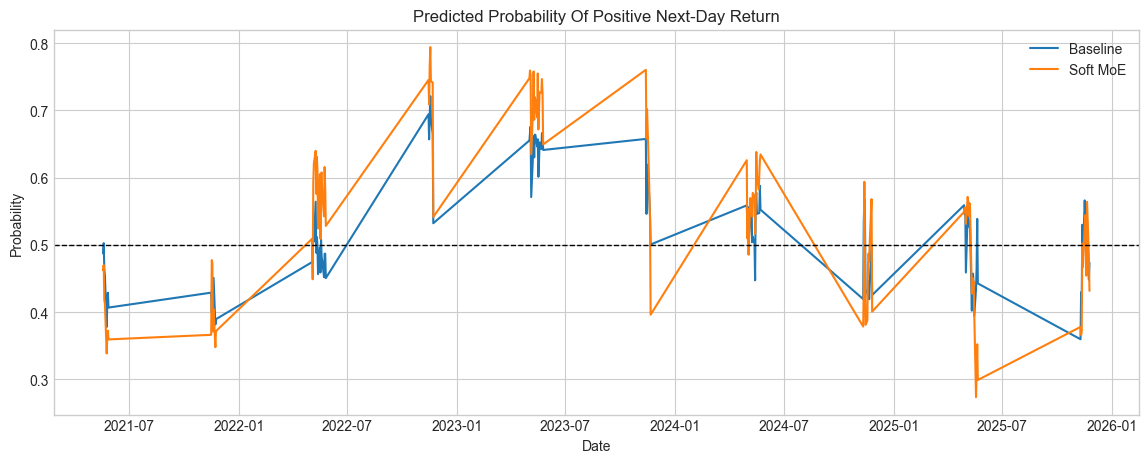

In [14]:
plt.figure(figsize=(14, 5))
plt.plot(predictions_df["Date"], predictions_df["baseline_up_prob"], label="Baseline")
plt.plot(predictions_df["Date"], predictions_df["soft_moe_up_prob"], label="Soft MoE")
plt.axhline(0.50, color="black", linestyle="--", linewidth=1)
plt.title("Predicted Probability Of Positive Next-Day Return")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.show()

## 13. Equity Curves

This tests a simple long/cash strategy using model probabilities.

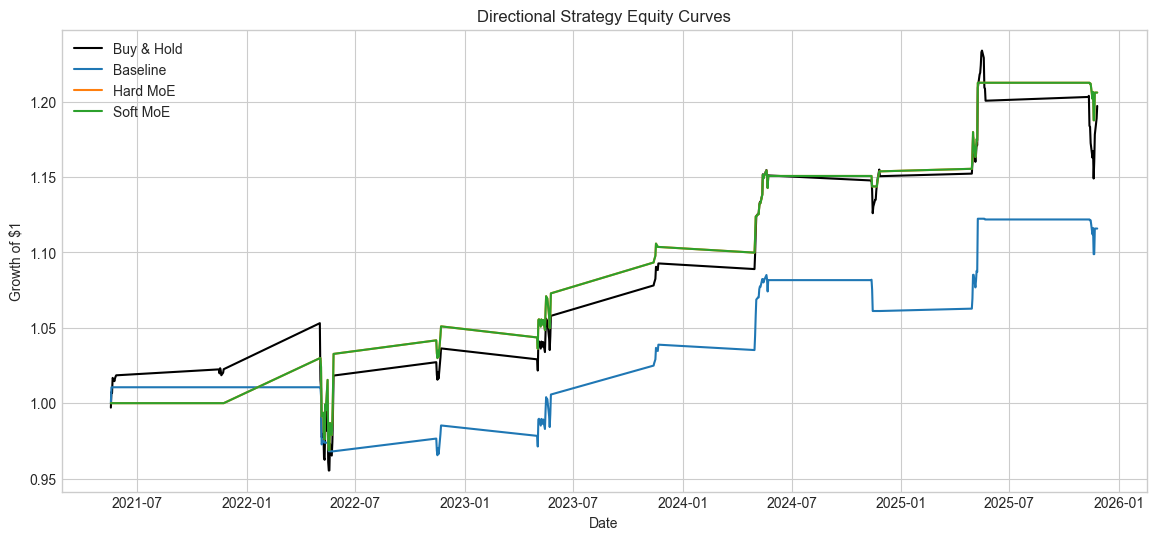

In [15]:
threshold = 0.50

equity_df = predictions_df[["Date", return_col]].copy()
equity_df["buy_hold"] = (1 + equity_df[return_col]).cumprod()
equity_df["baseline_strategy"] = (1 + strategy_returns(equity_df[return_col], predictions_df["baseline_up_prob"], threshold)).cumprod()
equity_df["hard_moe_strategy"] = (1 + strategy_returns(equity_df[return_col], predictions_df["hard_moe_up_prob"], threshold)).cumprod()
equity_df["soft_moe_strategy"] = (1 + strategy_returns(equity_df[return_col], predictions_df["soft_moe_up_prob"], threshold)).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(equity_df["Date"], equity_df["buy_hold"], label="Buy & Hold", color="black")
plt.plot(equity_df["Date"], equity_df["baseline_strategy"], label="Baseline")
plt.plot(equity_df["Date"], equity_df["hard_moe_strategy"], label="Hard MoE")
plt.plot(equity_df["Date"], equity_df["soft_moe_strategy"], label="Soft MoE")
plt.title("Directional Strategy Equity Curves")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()

## 14. Final Interpretation

Use these points in your project report:

1. Regression on daily returns is noisy.
2. Direction classification is more realistic for first-stage financial ML.
3. Regime-aware experts may improve risk-adjusted performance even if raw accuracy is similar.
4. Threshold tuning controls the trade-off between trade frequency and confidence.

Next research upgrade:

- Use walk-forward validation
- Use XGBoost or LightGBM
- Use all assets, not only S&P 500
- Replace HMM probabilities with a learned gating network